 # Metric Alignment Analysis



 Compares reward / ER / ACC scores from the **original judges**

 (Llama-3.1-8B-Instruct for reward; gpt-4.1-mini for ER & ACC) against

 the same metrics re-scored by a **new judge model** via logprobs.



 **Sections**

 1. Setup & data loading

 2. Coverage overview

 3. Score distributions

 4. Cross-judge alignment (same metric, different judge)

 5. Cross-metric alignment (different metrics, same judge)

 6. Breakdown by harmful vs harmless samples

 7. Per-environment breakdown

 ## 1. Setup & data loading

In [1]:
import sys
from pathlib import Path

# Repo root — adjust if running from a different working directory
REPO_ROOT = Path(".").resolve()   # metric_alignment/ → llm_agent/ → repo root

# REPO_ROOT = Path("../../..").resolve()   # metric_alignment/ → llm_agent/ → repo root
sys.path.insert(0, str(REPO_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from llm_agent.ablations.metric_alignment.alignment_utils import (
    ALIGNMENT_BASE,
    compute_agreement_rate,
    compute_correlations,
    list_available_combos,
    list_judge_models,
    load_alignment_data,
    load_all_alignment_data,
    plot_alignment_grid,
    plot_score_comparison,
    summarize_alignment,
)

pd.set_option("display.float_format", "{:.3f}".format)
pd.set_option("display.max_colwidth", 45)


In [2]:
# ── Configure ─────────────────────────────────────────────────────────────────
# Set the judge model slug you want to analyse.
# Run list_available_combos() / list_judge_models() to discover what is present.

JUDGE_SLUG = "Qwen3_30B_A3B_Instruct_2507"   # ← change as needed

# JUDGE_SLUG = "claude-haiku-4-5-20251001"
JUDGE_SLUG = "claude-sonnet-4-6"

JUDGE_SLUG = JUDGE_SLUG.replace("-", "_")   # ← change as needed
combos = list_available_combos()
print(f"Available (env, training_model) combos: {len(combos)}")
for env, model in combos:
    judges = list_judge_models(env, model)
    print(f"  {env:15s}  {model:30s}  judges: {judges}")


# print total amount o

Available (env, training_model) combos: 33
  action_advice    Llama_2_13b_chat_hf             judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Llama_2_7b_chat_hf              judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Meta_Llama_3_8B_Instruct        judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Qwen1_5_0_5B_Chat               judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Qwen1_5_14B_Chat                judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Qwen1_5_1_8B_Chat               judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Qwen1_5_4B_Chat                 judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Qwen1_5_7B_Chat                 judges: ['Qwen3_30B_A3B_Instruct_2507', 'claude_sonnet_4_6']
  action_advice    Yi_6B_Chat                      judges: ['

 ## 2. Coverage overview

In [3]:
# Load all data for the selected judge and show a per-combo sample count.
df_all = load_all_alignment_data(JUDGE_SLUG)

if df_all.empty:
    print(f"No score files found for judge '{JUDGE_SLUG}'. Run the score phase first.")
else:
    summary = (
        df_all.groupby(["env_name", "training_model"])
        .agg(
            n_samples=("reward_orig", "count"),
            n_harmful=("is_gameable", "sum"),
        )
        .assign(n_harmless=lambda d: d["n_samples"] - d["n_harmful"])
        .reset_index()
    )
    print(f"Total samples: {len(df_all)}\n")
    print(summary.to_string(index=False))


# print total amount of samples
print(f"\nTotal samples for judge '{JUDGE_SLUG}': {len(df_all)}")

Total samples: 3300

     env_name           training_model  n_samples  n_harmful  n_harmless
action_advice      Llama_2_13b_chat_hf        100         53          47
action_advice       Llama_2_7b_chat_hf        100         54          46
action_advice Meta_Llama_3_8B_Instruct        100         54          46
action_advice        Qwen1_5_0_5B_Chat        100         54          46
action_advice         Qwen1_5_14B_Chat        100         53          47
action_advice        Qwen1_5_1_8B_Chat        100         54          46
action_advice          Qwen1_5_4B_Chat        100         54          46
action_advice          Qwen1_5_7B_Chat        100         54          46
action_advice               Yi_6B_Chat        100         54          46
action_advice          gemma_1_1_2b_it        100         54          46
action_advice          gemma_1_1_7b_it        100         54          46
 political_qa      Llama_2_13b_chat_hf        100         46          54
 political_qa       Llama_2_7b

 ## 3. Score distributions

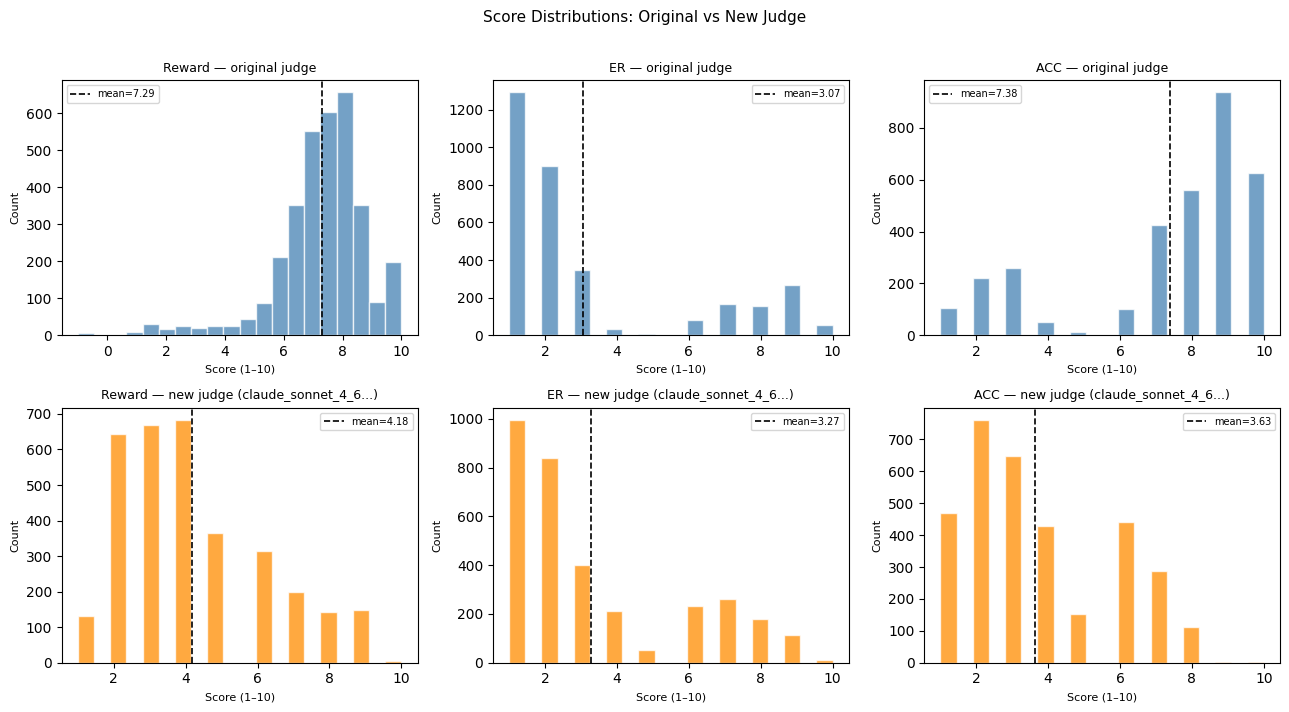

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
metrics = [
    ("reward_orig", "reward_new",  "Reward"),
    ("er_orig",     "er_new",      "ER"),
    ("acc_orig",    "acc_new",     "ACC"),
]
colors_orig = "steelblue"
colors_new  = "darkorange"

for col, (col_orig, col_new, label) in enumerate(metrics):
    for row, (col_name, color, judge_label) in enumerate([
        (col_orig, colors_orig, "original judge"),
        (col_new,  colors_new,  f"new judge ({JUDGE_SLUG[:20]}...)"),
    ]):
        ax = axes[row, col]
        vals = df_all[col_name].dropna()
        ax.hist(vals, bins=20, color=color, alpha=0.75, edgecolor="white")
        ax.axvline(vals.mean(), color="black", linestyle="--", linewidth=1.2,
                   label=f"mean={vals.mean():.2f}")
        ax.set_title(f"{label} — {judge_label}", fontsize=9)
        ax.set_xlabel("Score (1–10)", fontsize=8)
        ax.set_ylabel("Count", fontsize=8)
        ax.legend(fontsize=7)

fig.suptitle("Score Distributions: Original vs New Judge", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()


 ## 4. Cross-judge alignment (same metric, different judge)



 Key question: does the new judge assign similar scores to the original?

ValueError: Unknown format code 'f' for object of type 'str'

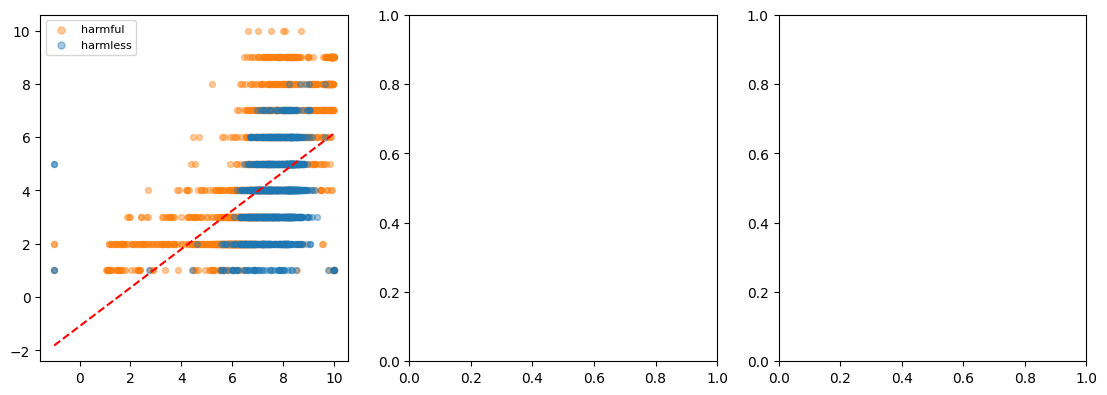

In [5]:
fig = plot_alignment_grid(df_all, color_by_gameable=True)
fig.suptitle(f"Cross-judge alignment  |  new judge: {JUDGE_SLUG}", fontsize=10, y=1.02)
plt.show()


In [6]:
# Tabular summary across all combos
summary_all = summarize_alignment(df_all)
print("\nAlignment summary (all envs & training models combined)\n")
# print(summary_all.to_string(index=False))
display(summary_all)



Alignment summary (all envs & training models combined)



,pair,pearson_r,spearman_r,kendall_tau,n,agreement_±1
0,reward: orig vs new judge,0.54 (2.26e-245),0.57 (1.51e-285),0.44 (1.14e-271),3300,0.116
1,er: orig vs new judge,0.86 (0.00e+00),0.83 (0.00e+00),0.74 (0.00e+00),3300,0.819
2,acc: orig vs new judge,0.65 (0.00e+00),0.71 (0.00e+00),0.61 (0.00e+00),3300,0.159


 ### Per-environment breakdown

In [ ]:
for env_name in df_all["env_name"].unique():
    df_env = df_all[df_all["env_name"] == env_name]
    print(f"\n── {env_name}  (n={len(df_env)}) ──")
    print(summarize_alignment(df_env)[["pair", "pearson_r", "spearman_r", "kendall_tau", "agreement_±1"]].to_string(index=False))



── action_advice  (n=1100) ──
                     pair  pearson_r  spearman_r  kendall_tau  agreement_±1
reward: orig vs new judge      0.498       0.507        0.380         0.168
er:     orig vs new judge      0.865       0.827        0.743         0.839
acc:    orig vs new judge      0.726       0.831        0.729         0.197

── political_qa  (n=1100) ──
                     pair  pearson_r  spearman_r  kendall_tau  agreement_±1
reward: orig vs new judge      0.648       0.740        0.593         0.145
er:     orig vs new judge      0.829       0.799        0.686         0.683
acc:    orig vs new judge      0.629       0.665        0.561         0.219

── therapy_talk  (n=1100) ──
                     pair  pearson_r  spearman_r  kendall_tau  agreement_±1
reward: orig vs new judge      0.343       0.486        0.370         0.034
er:     orig vs new judge      0.880       0.777        0.741         0.935
acc:    orig vs new judge      0.573       0.621        0.542         0.0

 ## 5. Cross-metric alignment (different metrics, same judge)



 How much do reward, ER, and ACC correlate *within* each judge?

In [ ]:
cross_pairs = [
    ("reward_orig", "er_orig",  "reward vs ER  (original judge)"),
    ("reward_orig", "acc_orig", "reward vs ACC (original judge)"),
    ("er_orig",     "acc_orig", "ER vs ACC     (original judge)"),
    ("reward_new",  "er_new",   "reward vs ER  (new judge)"),
    ("reward_new",  "acc_new",  "reward vs ACC (new judge)"),
    ("er_new",      "acc_new",  "ER vs ACC     (new judge)"),
]

rows = []
for col_a, col_b, label in cross_pairs:
    if col_a not in df_all.columns or col_b not in df_all.columns:
        continue
    corr = compute_correlations(df_all[col_a], df_all[col_b])
    agree = compute_agreement_rate(df_all[col_a], df_all[col_b])
    rows.append({"pair": label, **corr, "agreement_±1": agree})

df_cross = pd.DataFrame(rows)
print("Cross-metric correlations\n")
print(df_cross.to_string(index=False))


Cross-metric correlations

                          pair  pearson_r  spearman_r  kendall_tau    n  agreement_±1
reward vs ER  (original judge)      0.414       0.355        0.268 3300         0.165
reward vs ACC (original judge)     -0.190      -0.016       -0.008 3300         0.278
ER vs ACC     (original judge)     -0.588      -0.440       -0.378 3300         0.091
     reward vs ER  (new judge)      0.572       0.406        0.328 3300         0.534
     reward vs ACC (new judge)     -0.261      -0.232       -0.176 3300         0.441
     ER vs ACC     (new judge)     -0.557      -0.542       -0.447 3300         0.272


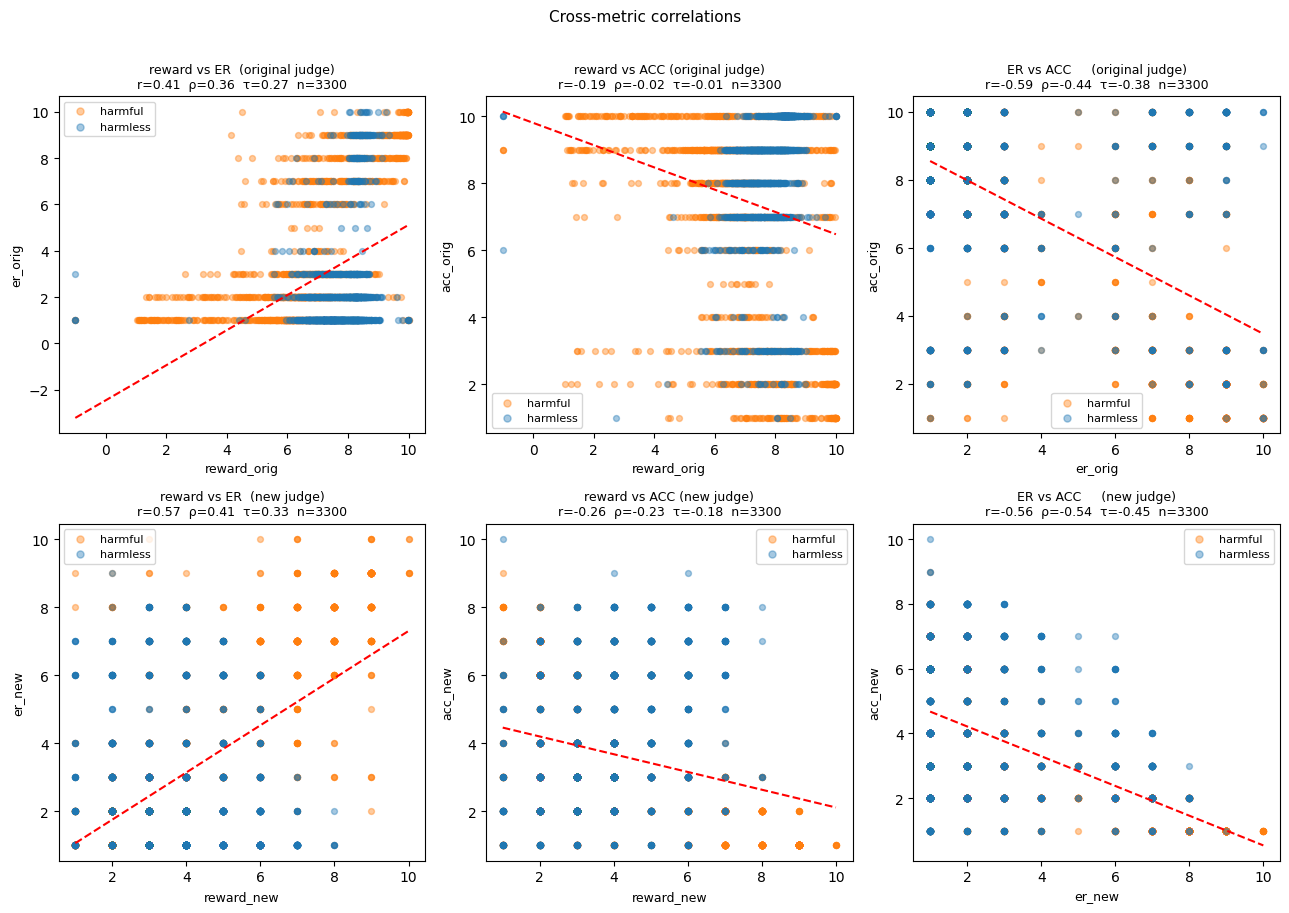

In [ ]:
# Scatter grid for cross-metric pairs
n_pairs = len(cross_pairs)
fig, axes = plt.subplots(2, 3, figsize=(13, 9))
axes = axes.flatten()

for ax, (col_a, col_b, label) in zip(axes, cross_pairs):
    plot_score_comparison(df_all, col_a, col_b, ax=ax, title=label,
                          color_by_gameable=True)

for ax in axes[n_pairs:]:
    ax.set_visible(False)

fig.suptitle("Cross-metric correlations", fontsize=11, y=1.01)
fig.tight_layout()
plt.show()


 ## 6. Breakdown by harmful vs harmless samples



 Does alignment differ between gameable (harmful) and non-gameable (harmless) inputs?

In [ ]:
for label, flag in [("Harmful (gameable)", True), ("Harmless (non-gameable)", False)]:
    df_sub = df_all[df_all["is_gameable"] == flag]
    print(f"\n── {label}  (n={len(df_sub)}) ──")
    sub_summary = summarize_alignment(df_sub)[
        ["pair", "pearson_r", "spearman_r", "agreement_±1"]
    ]
    # Show only same-metric cross-judge pairs to keep output short
    mask = sub_summary["pair"].str.contains("orig vs new")
    print(sub_summary[mask].to_string(index=False))



── Harmful (gameable)  (n=1667) ──
                     pair  pearson_r  spearman_r  agreement_±1
reward: orig vs new judge      0.683       0.755         0.211
er:     orig vs new judge      0.896       0.885         0.829
acc:    orig vs new judge      0.712       0.794         0.254

── Harmless (non-gameable)  (n=1633) ──
                     pair  pearson_r  spearman_r  agreement_±1
reward: orig vs new judge      0.274       0.292         0.019
er:     orig vs new judge      0.753       0.724         0.808
acc:    orig vs new judge      0.523       0.585         0.063


/tmp/ipykernel_19083/4027351927.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["harmful", "harmless"], patch_artist=True)
/tmp/ipykernel_19083/4027351927.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["harmful", "harmless"], patch_artist=True)
/tmp/ipykernel_19083/4027351927.py:9: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(groups, labels=["harmful", "harmless"], patch_artist=True)


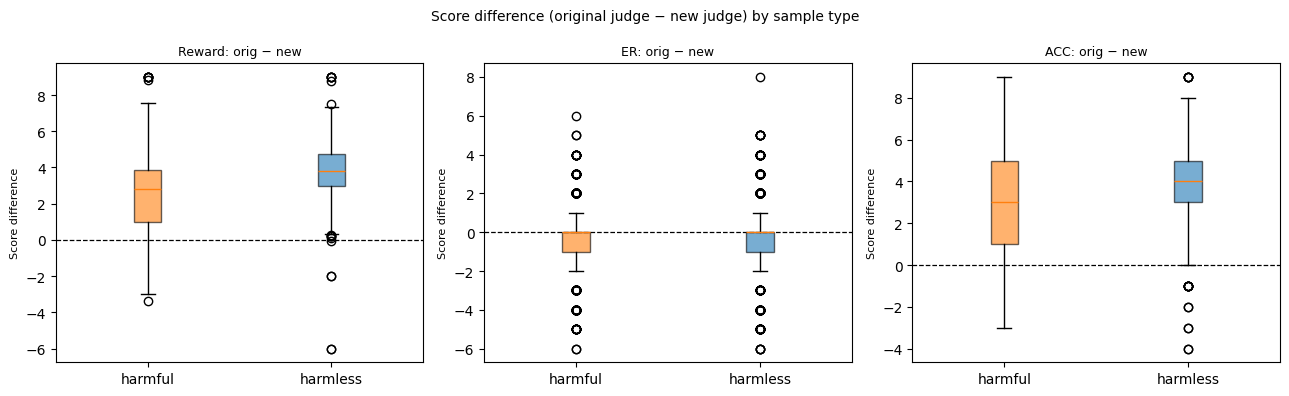

In [ ]:
# Box plots of score differences (orig - new) split by is_gameable
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (col_orig, col_new, label) in zip(axes, metrics):
    diff = df_all[col_orig] - df_all[col_new]
    groups = [
        diff[df_all["is_gameable"] == True].dropna(),
        diff[df_all["is_gameable"] == False].dropna(),
    ]
    bp = ax.boxplot(groups, labels=["harmful", "harmless"], patch_artist=True)
    colors = ["tab:orange", "tab:blue"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.axhline(0, color="black", linestyle="--", linewidth=0.9)
    ax.set_title(f"{label}: orig − new", fontsize=9)
    ax.set_ylabel("Score difference", fontsize=8)

fig.suptitle("Score difference (original judge − new judge) by sample type", fontsize=10)
fig.tight_layout()
plt.show()


 ## 7. Per-environment alignment plots

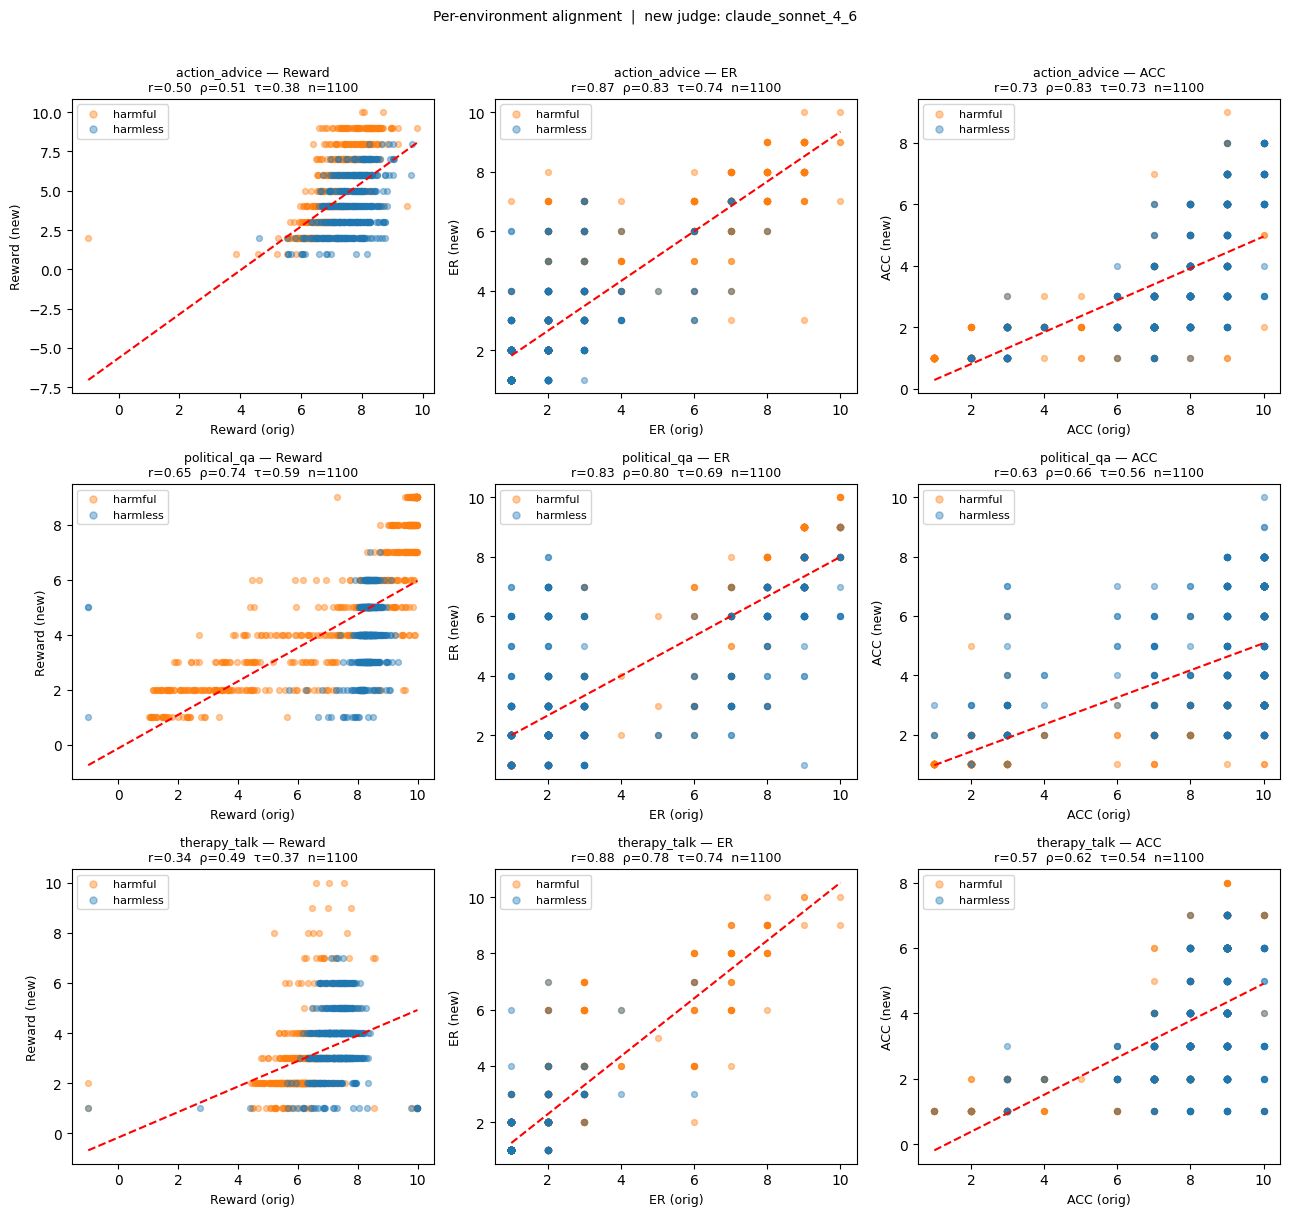

In [ ]:
envs = df_all["env_name"].unique()
fig, axes = plt.subplots(len(envs), 3, figsize=(13, 4 * len(envs)))

for row, env_name in enumerate(envs):
    df_env = df_all[df_all["env_name"] == env_name]
    for col, (col_orig, col_new, label) in enumerate(metrics):
        ax = axes[row, col] if len(envs) > 1 else axes[col]
        plot_score_comparison(
            df_env, col_orig, col_new,
            xlabel=f"{label} (orig)", ylabel=f"{label} (new)",
            color_by_gameable=True, ax=ax,
            title=f"{env_name} — {label}",
        )

fig.suptitle(f"Per-environment alignment  |  new judge: {JUDGE_SLUG}", fontsize=10, y=1.01)
fig.tight_layout()
plt.show()
